# 02. 피처 선택

01의 상관은 참고일 뿐이다. 여기서는 **개발 구간의 walk-forward 성능**으로 지평별 피처 묶음을 정한다. 2012–2021년 각 해를 그 전까지의 자료(2006년~)로 학습한 모델로 예측하고, 10개 연도의 예측을 이어 붙여 평가한다.

- 묶음: 가격(8) / 가격+주기(12) / 가격+거시(13) / 가격+기후(37) / 전체(46)
- 수익률 회귀: 변동성으로 정규화한 Ridge·LightGBM, Naive 대비 RMSE
- 방향 확률: LightGBM 분류기의 AUC(상승한 날에 더 높은 확률을 줬는지, 0.5면 구분 못 함)

**선택 규칙 (결과를 보기 전에 정함).** 03에서 쓸 방향 모델의 묶음은 AUC가 가장 높은 것을 고른다. 차이가 0.005 이내면 피처가 적은 쪽을 고른다. 수익률 회귀의 묶음은 두 모델의 평균 RMSE가 가장 낮은 것을 고른다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

import common
from coffee.config import DEV_YEARS, HORIZONS
from coffee.evaluate import fold_rows
from coffee.features import ALL_FEATURES, FEATURE_GROUPS, build_dataset
from coffee.models import LightGBMClassifier, LightGBMModel, RidgeModel, ScaledReturn
from coffee.sources import load_sources

data = build_dataset(load_sources())
G = FEATURE_GROUPS
GROUPS = {  # 피처 수가 적은 순서
    "가격": G["price"], "가격+주기": G["price"] + G["cycle"], "가격+거시": G["price"] + G["macro"],
    "가격+기후": G["price"] + G["climate"], "전체": ALL_FEATURES,
}


def walk_forward(h, make):
    # 개발 구간 10개 연도의 예측을 이어 붙인다. 행은 모든 묶음에서 같다(전체 피처 기준).
    y_all, p_all = [], []
    y = data[f"y_{h}"].to_numpy()
    for year in DEV_YEARS:
        fit, test = fold_rows(data, ALL_FEATURES, h, year, DEV_YEARS[-1])
        p_all.append(make().fit(data, fit, y[fit]).predict(data, test))
        y_all.append(y[test])
    return np.concatenate(y_all), np.concatenate(p_all)


print({h: sum(len(fold_rows(data, ALL_FEATURES, h, year, DEV_YEARS[-1])[1]) for year in DEV_YEARS) for h in HORIZONS}, "개발 구간 평가 행")

{5: 2425, 20: 2410, 60: 2370} 개발 구간 평가 행


## 1. 피처 묶음 비교

In [2]:
records = []
for h in HORIZONS:
    y, _ = walk_forward(h, lambda: ScaledReturn(RidgeModel(["ret_1"]), h))
    naive_rmse = np.sqrt(np.mean(y ** 2))
    for group, features in GROUPS.items():
        row = {"지평": h, "묶음": group, "피처 수": len(features)}
        for label, make in (("Ridge", lambda f=features: ScaledReturn(RidgeModel(f, alpha=100), h)),
                            ("LightGBM", lambda f=features: ScaledReturn(LightGBMModel(f, n_estimators=150, num_leaves=7, min_child_samples=100), h))):
            _, predicted = walk_forward(h, make)
            row[f"{label} RMSE(Naive 대비 %)"] = 100 * (np.sqrt(np.mean((y - predicted) ** 2)) / naive_rmse - 1)
        _, prob = walk_forward(h, lambda f=features: LightGBMClassifier(f))
        moved = y != 0
        row["분류 AUC"] = roc_auc_score(y[moved] > 0, prob[moved])
        records.append(row)
groups = pd.DataFrame(records)
groups.set_index(["지평", "묶음"]).round(3)

피처 수  Ridge RMSE(Naive 대비 %)  LightGBM RMSE(Naive 대비 %)  분류 AUC
지평 묶음                                                                    
5  가격        8                   1.201                      0.939   0.512
   가격+주기    12                   1.868                      2.043   0.508
   가격+거시    13                  12.571                      1.815   0.517
   가격+기후    37                   7.421                      3.311   0.537
   전체       46                  22.845                      3.944   0.520
20 가격        8                   4.371                      3.815   0.535
   가격+주기    12                   6.575                     10.640   0.526
   가격+거시    13                  10.495                      5.856   0.542
   가격+기후    37                  23.269                     13.351   0.583
   전체       46                  38.544                     11.196   0.577
60 가격        8                   4.929                     14.269   0.396
   가격+주기    12                   5.199                     21.101   0.395
   가격+거시    13                   6.981                     15.712   0.466
   가격+기후    37                  21.206                     11.520   0.581
   전체       46                  32.443                     13.721   0.556

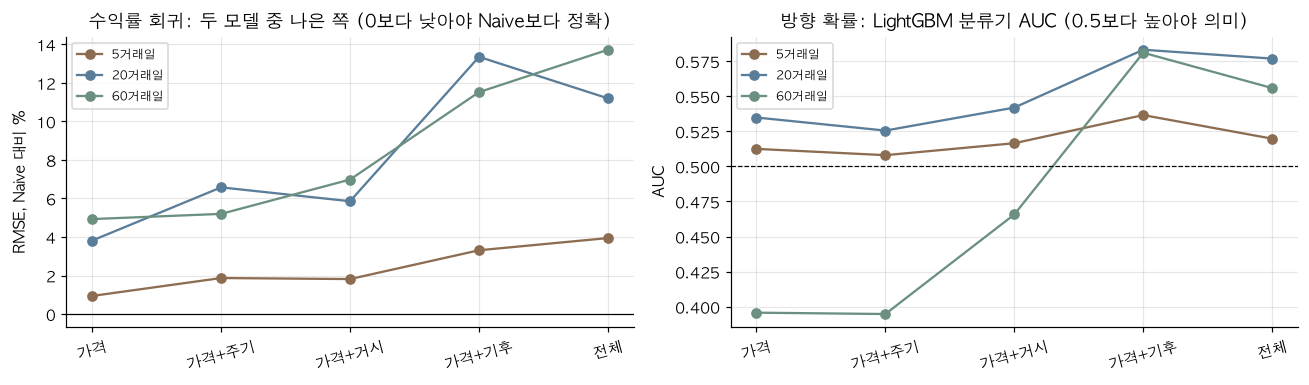

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for h, color in zip(HORIZONS, ["#8c6d52", "#5a7d9a", "#6b9080"]):
    table = groups[groups["지평"] == h].set_index("묶음")
    axes[0].plot(table.index, table[["Ridge RMSE(Naive 대비 %)", "LightGBM RMSE(Naive 대비 %)"]].min(axis=1),
                 marker="o", color=color, label=f"{h}거래일")
    axes[1].plot(table.index, table["분류 AUC"], marker="o", color=color, label=f"{h}거래일")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(title="수익률 회귀: 두 모델 중 나은 쪽 (0보다 낮아야 Naive보다 정확)", ylabel="RMSE, Naive 대비 %")
axes[1].axhline(0.5, color="black", lw=0.8, ls="--")
axes[1].set(title="방향 확률: LightGBM 분류기 AUC (0.5보다 높아야 의미)", ylabel="AUC")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
fig.tight_layout()
common.save_fig(fig, "feature_groups.png")
plt.show()

**수익률 회귀는 어떤 묶음도 Naive를 넘지 못했다.** 피처를 더할수록 오히려 나빠지고, 특히 기후 피처가 들어간 Ridge는 지평에 따라 7~39% 나빠졌다. 가격의 '크기'를 맞히려 하면 약한 신호보다 잡음을 더 많이 배운다.

**방향 확률은 사정이 다르다.** 세 지평 모두 가격+기후 묶음의 AUC가 가장 높다. 60일은 가격만 쓰면 AUC 0.40으로 무작위보다 나쁜데, 기후를 더하면 0.58이 된다. 01에서 본 대로 기후처럼 천천히 움직이는 정보는 긴 지평의 방향에 담겨 있다. 거시(환율·운임)와 해거리 주기는 방향에도 거의 도움이 되지 않았다.

In [4]:
choice = {}
for h in HORIZONS:
    table = groups[groups["지평"] == h].set_index("묶음")
    direction = [group for group in GROUPS if table.loc[group, "분류 AUC"] >= table["분류 AUC"].max() - 0.005][0]
    regression = table[["Ridge RMSE(Naive 대비 %)", "LightGBM RMSE(Naive 대비 %)"]].mean(axis=1).idxmin()
    choice[h] = {"direction": direction, "regression": regression}
    print(f"{h}거래일 — 방향: {direction} (AUC {table.loc[direction, '분류 AUC']:.3f}), 회귀: {regression}")

5거래일 — 방향: 가격+기후 (AUC 0.537), 회귀: 가격
20거래일 — 방향: 가격+기후 (AUC 0.583), 회귀: 가격
60거래일 — 방향: 가격+기후 (AUC 0.581), 회귀: 가격


## 2. 방향 모델이 기대는 피처 (permutation importance)

fold마다 학습한 분류기에서, 그해 평가 행의 피처 하나를 무작위로 섞었을 때 AUC가 얼마나 떨어지는지 10개 연도 평균으로 본다. 해석용이며 선택 규칙에는 쓰지 않는다.

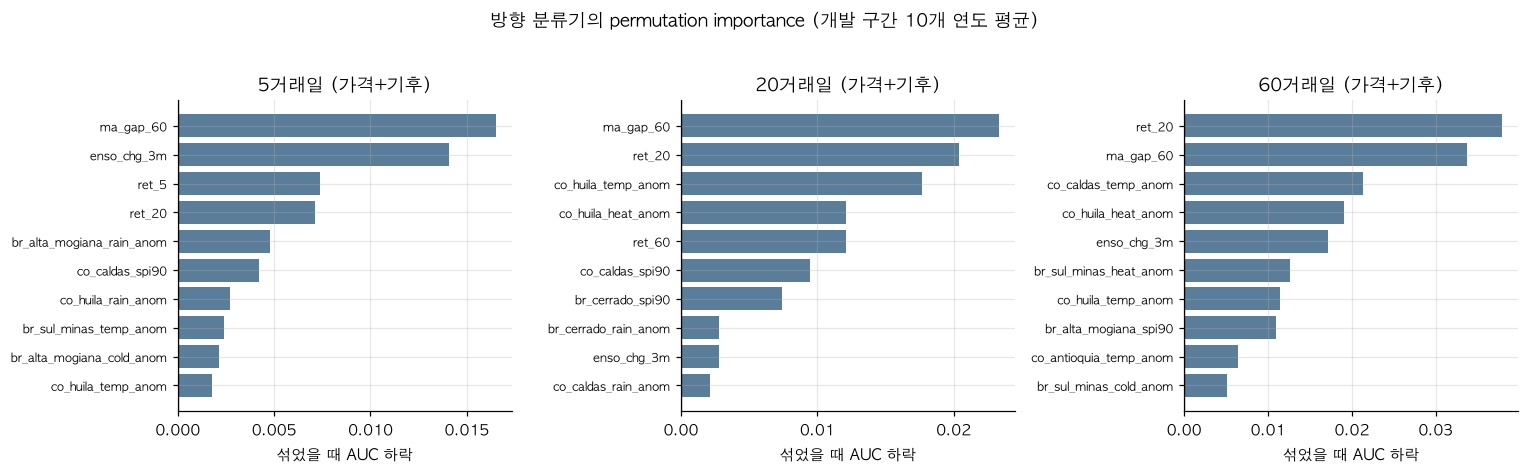

In [5]:
rng = np.random.default_rng(42)
importance = {}
for h in HORIZONS:
    features = GROUPS[choice[h]["direction"]]
    y = data[f"y_{h}"].to_numpy()
    drops = {feature: [] for feature in features}
    for year in DEV_YEARS:
        fit, test = fold_rows(data, ALL_FEATURES, h, year, DEV_YEARS[-1])
        model = LightGBMClassifier(features).fit(data, fit, y[fit])
        moved = y[test] != 0
        base = roc_auc_score(y[test][moved] > 0, model.predict(data, test)[moved])
        for feature in features:
            shuffled = data.copy()
            column = shuffled.columns.get_loc(feature)
            shuffled.iloc[test, column] = rng.permutation(shuffled.iloc[test, column].to_numpy())
            drops[feature].append(base - roc_auc_score(y[test][moved] > 0, model.predict(shuffled, test)[moved]))
    importance[h] = pd.Series({feature: np.mean(values) for feature, values in drops.items()}).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, h in zip(axes, HORIZONS):
    top = importance[h].tail(10)
    ax.barh(top.index, top.values, color=["#b5838d" if value < 0 else "#5a7d9a" for value in top.values])
    ax.axvline(0, color="black", lw=0.8)
    ax.set(title=f"{h}거래일 ({choice[h]['direction']})", xlabel="섞었을 때 AUC 하락")
    ax.tick_params(axis="y", labelsize=8)
    ax.locator_params(axis="x", nbins=4)  # 눈금 글자가 겹치지 않게
fig.suptitle("방향 분류기의 permutation importance (개발 구간 10개 연도 평균)", y=1.02)
fig.tight_layout()
common.save_fig(fig, "permutation_importance.png")
plt.show()

세 지평 모두 최근 가격의 위치(60일 이동평균 괴리, 20일 수익률)에 가장 많이 기댄다. 그 다음이 기후다. 5일은 ENSO의 3개월 변화가 두 번째로 컸고, 20일은 콜롬비아 우일라의 기온·고온일과 칼다스·세하두의 90일 강수 지수, 60일은 콜롬비아 칼다스의 기온, 우일라의 고온일, ENSO 변화가 쓰였다. 특정 지점 하나가 아니라 여러 지점의 기후가 조금씩 기여한다.

In [6]:
common.save_result("feature_sets", {str(h): {"direction": GROUPS[choice[h]["direction"]], "direction_group": choice[h]["direction"],
                                             "regression": GROUPS[choice[h]["regression"]], "regression_group": choice[h]["regression"]}
                                    for h in HORIZONS})

## 정리

- 수익률 회귀는 어떤 피처 묶음으로도 Naive를 넘지 못했다. 03에서는 가장 덜 나쁜 '가격' 묶음으로 확인만 한다.
- 방향 확률은 가격+기후 묶음이 세 지평 모두 가장 좋았다(AUC 0.54~0.58). 크지 않지만 무작위(0.5)보다는 낫다.
- 거시 지표(환율·금리·유가·운임)와 해거리 주기는 이 비교에서 도움이 되지 않았다. 해거리는 작물년도 단위의 신호라 20년 표본으로는 배울 반복이 10번뿐이다.